In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [154]:
high = pd.read_csv('neonatal_high_burden.csv')
high.head()

,id,sex,gestational_age_weeks,birth_weight_g,head_circumference_cm,maternal_age_years,parity,delivery_mode,apgar_1min,apgar_5min,temperature_c,heart_rate_bpm,respiratory_rate_bpm,spo2_percent,bw_category,preterm_category,primary_outcome
0,1,F,35.0,2610,42.0,24,2,vaginal,6,8,37.1,143,55,94,Normal_BW,Late_preterm,healthy
1,2,M,37.6,2490,39.4,15,0,vaginal,8,7,37.3,125,48,97,LBW,Term,neonatal_sepsis
2,3,F,36.6,2500,20.2,27,1,vaginal,8,4,37.0,129,45,98,Normal_BW,Late_preterm,healthy
3,4,F,39.0,3230,42.0,31,4,vaginal,9,7,36.9,149,37,98,Normal_BW,Term,healthy
4,5,M,38.1,3470,37.2,27,0,vaginal,7,10,36.8,181,52,96,Normal_BW,Term,healthy


In [155]:
low = pd.read_csv('neonatal_low_burden.csv')
low.head()

,id,sex,gestational_age_weeks,birth_weight_g,head_circumference_cm,maternal_age_years,parity,delivery_mode,apgar_1min,apgar_5min,temperature_c,heart_rate_bpm,respiratory_rate_bpm,spo2_percent,bw_category,preterm_category,primary_outcome
0,1,F,36.3,2860,39.8,24,2,vaginal,7,6,36.8,134,45,97,Normal_BW,Late_preterm,healthy
1,2,M,37.8,2640,34.0,15,0,vaginal,9,9,36.5,144,53,95,Normal_BW,Term,healthy
2,3,F,39.6,3010,41.4,27,1,vaginal,9,10,37.2,149,55,98,Normal_BW,Term,healthy
3,4,F,39.0,3230,34.6,31,4,vaginal,9,9,36.7,160,51,98,Normal_BW,Term,healthy
4,5,M,39.0,3630,35.2,27,0,caesarean,9,9,36.9,147,43,98,Normal_BW,Term,healthy


In [156]:
moderate = pd.read_csv('neonatal_moderate_burden.csv')
moderate.head()

,id,sex,gestational_age_weeks,birth_weight_g,head_circumference_cm,maternal_age_years,parity,delivery_mode,apgar_1min,apgar_5min,temperature_c,heart_rate_bpm,respiratory_rate_bpm,spo2_percent,bw_category,preterm_category,primary_outcome
0,1,F,35.4,2690,26.6,24,2,vaginal,6,3,37.2,154,53,97,Normal_BW,Late_preterm,healthy
1,2,M,37.1,2830,38.5,15,0,vaginal,4,4,36.9,93,44,83,Normal_BW,Term,birth_asphyxia
2,3,F,37.1,2600,36.3,27,1,vaginal,10,8,36.8,120,51,94,Normal_BW,Term,healthy
3,4,F,39.3,3280,34.9,31,4,vaginal,9,7,37.1,141,54,95,Normal_BW,Term,healthy
4,5,M,38.5,3540,42.0,27,0,vaginal,8,9,37.0,157,49,99,Normal_BW,Term,healthy


In [157]:
# Add a new column to each DataFrame to indicate the burden level
high["burden_level"] = "high"
low["burden_level"] = "low"
moderate["burden_level"] = "moderate"

# Combine the DataFrames into a single DataFrame
df = pd.concat([high, low, moderate], axis=0)

# Shuffle the combined DataFrame
df = df.sample(frac=1, random_state=52).reset_index(drop=True)

df.head()

,id,sex,gestational_age_weeks,birth_weight_g,head_circumference_cm,maternal_age_years,parity,delivery_mode,apgar_1min,apgar_5min,temperature_c,heart_rate_bpm,respiratory_rate_bpm,spo2_percent,bw_category,preterm_category,primary_outcome,burden_level
0,7968,F,38.2,2730,37.0,16,0,vaginal,9,10,36.7,147,48,96,Normal_BW,Term,healthy,moderate
1,5442,F,39.8,2260,34.8,17,0,vaginal,5,9,36.7,125,43,97,LBW,Term,low_birth_weight_term,high
2,2705,F,37.1,3030,39.4,20,2,vaginal,9,9,36.4,120,47,97,Normal_BW,Term,healthy,high
3,7886,M,39.7,3130,18.1,15,0,vaginal,8,10,36.8,143,54,96,Normal_BW,Term,healthy,moderate
4,3572,M,40.5,2870,34.1,23,1,vaginal,8,7,37.2,108,46,97,Normal_BW,Term,low_birth_weight_term,low


In [158]:
df.describe()

,id,gestational_age_weeks,birth_weight_g,head_circumference_cm,maternal_age_years,parity,apgar_1min,apgar_5min,temperature_c,heart_rate_bpm,respiratory_rate_bpm,spo2_percent
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.00000
mean,5000.500000,37.896707,2851.544667,32.732983,25.813900,2.478700,7.432033,8.040633,36.738807,138.956867,49.101567,96.14820
std,2886.799445,2.578925,600.447582,7.761193,5.678762,2.124028,1.946546,1.835346,0.562219,15.350728,7.761056,3.05406
min,1.000000,24.100000,400.000000,18.000000,14.000000,0.000000,0.000000,0.000000,34.000000,61.000000,27.000000,73.00000
25%,2500.750000,36.700000,2480.000000,26.900000,22.000000,1.000000,7.000000,7.000000,36.600000,130.000000,44.000000,95.00000
50%,5000.500000,38.300000,2890.000000,33.600000,26.000000,2.000000,8.000000,9.000000,36.800000,140.000000,48.000000,97.00000
75%,7500.250000,39.700000,3270.000000,40.500000,30.000000,4.000000,9.000000,9.000000,37.100000,149.000000,53.000000,98.00000
max,10000.000000,42.000000,4970.000000,42.000000,47.000000,14.000000,10.000000,10.000000,39.500000,196.000000,100.000000,100.00000


In [159]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

In [160]:
# Check for missing values
df.isnull().sum()

id                       0
sex                      0
gestational_age_weeks    0
birth_weight_g           0
head_circumference_cm    0
maternal_age_years       0
parity                   0
delivery_mode            0
apgar_1min               0
apgar_5min               0
temperature_c            0
heart_rate_bpm           0
respiratory_rate_bpm     0
spo2_percent             0
bw_category              0
preterm_category         0
primary_outcome          0
burden_level             0
dtype: int64

In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     30000 non-null  int64  
 1   sex                    30000 non-null  object 
 2   gestational_age_weeks  30000 non-null  float64
 3   birth_weight_g         30000 non-null  int64  
 4   head_circumference_cm  30000 non-null  float64
 5   maternal_age_years     30000 non-null  int64  
 6   parity                 30000 non-null  int64  
 7   delivery_mode          30000 non-null  object 
 8   apgar_1min             30000 non-null  int64  
 9   apgar_5min             30000 non-null  int64  
 10  temperature_c          30000 non-null  float64
 11  heart_rate_bpm         30000 non-null  int64  
 12  respiratory_rate_bpm   30000 non-null  int64  
 13  spo2_percent           30000 non-null  int64  
 14  bw_category            30000 non-null  object 
 15  pr

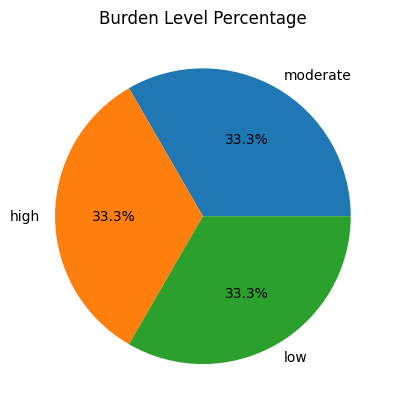

In [162]:
# Visualize the distribution of the burden levels
df["burden_level"].value_counts().plot.pie(autopct="%1.1f%%")
plt.ylabel("")
plt.title("Burden Level Percentage")
plt.show()

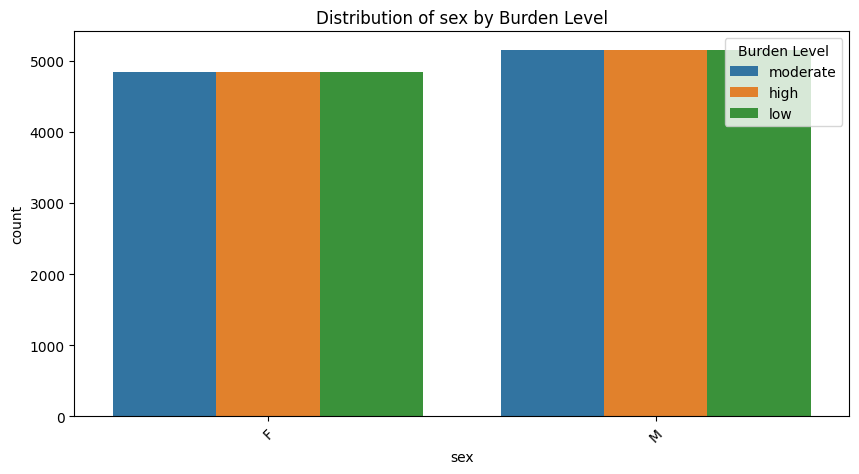

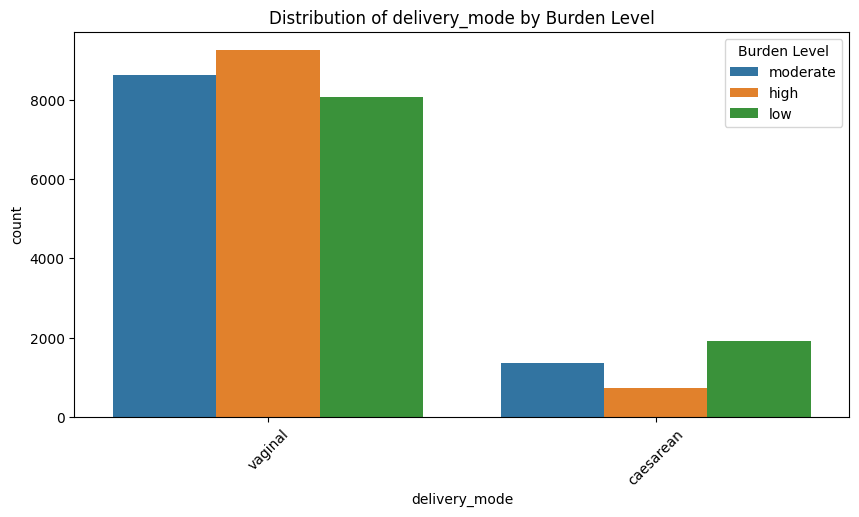

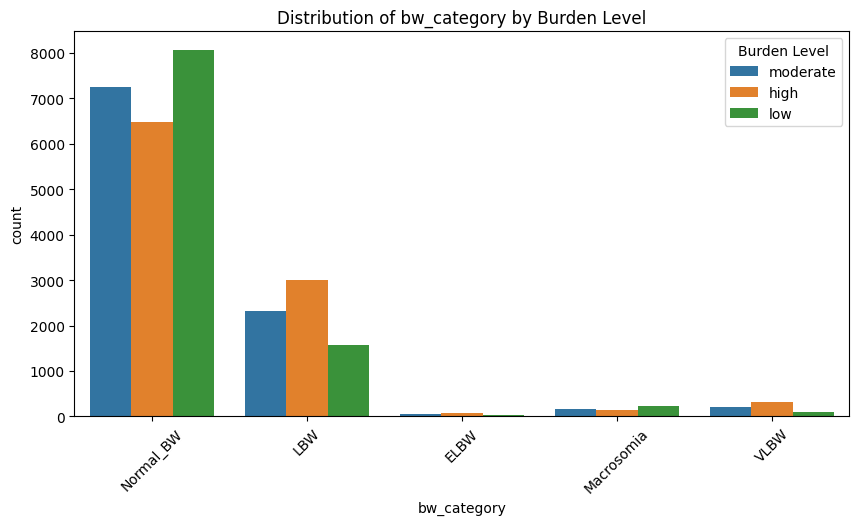

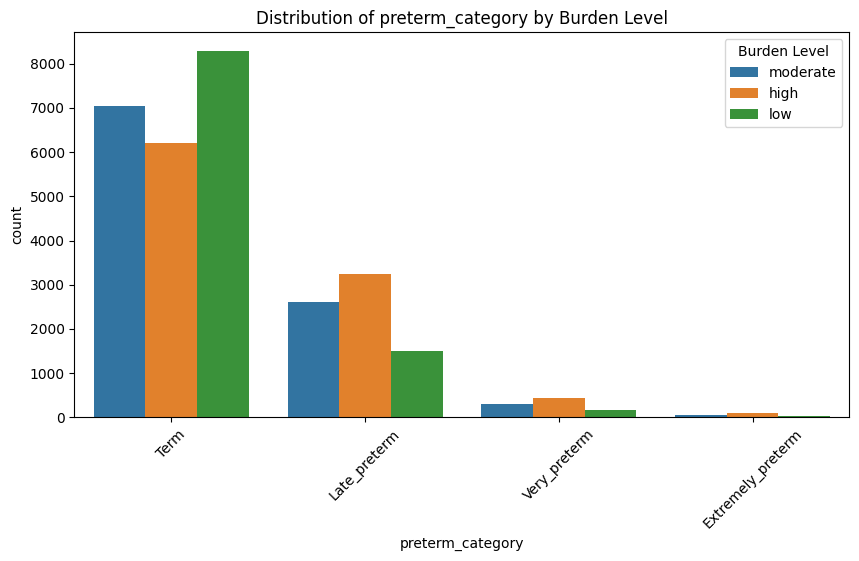

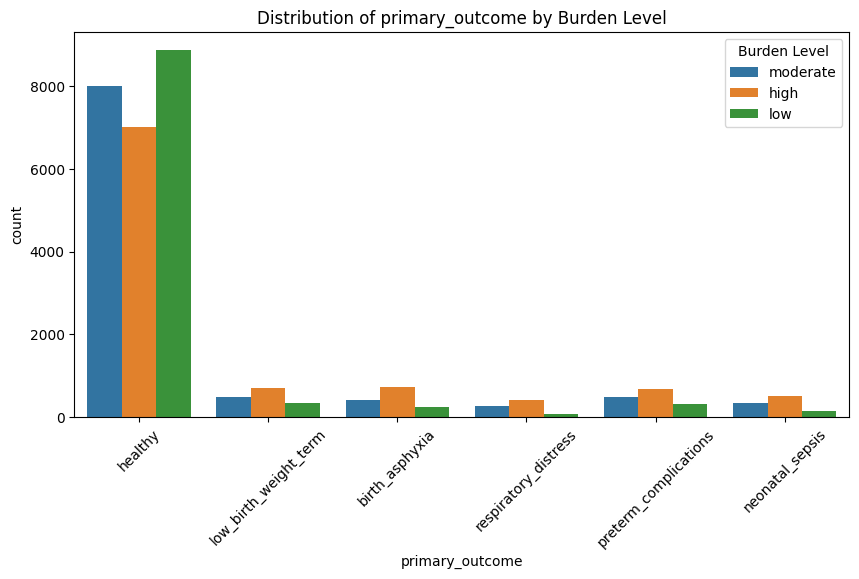

C:\Users\mable\AppData\Local\Temp\ipykernel_25112\1062809204.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Burden Level")


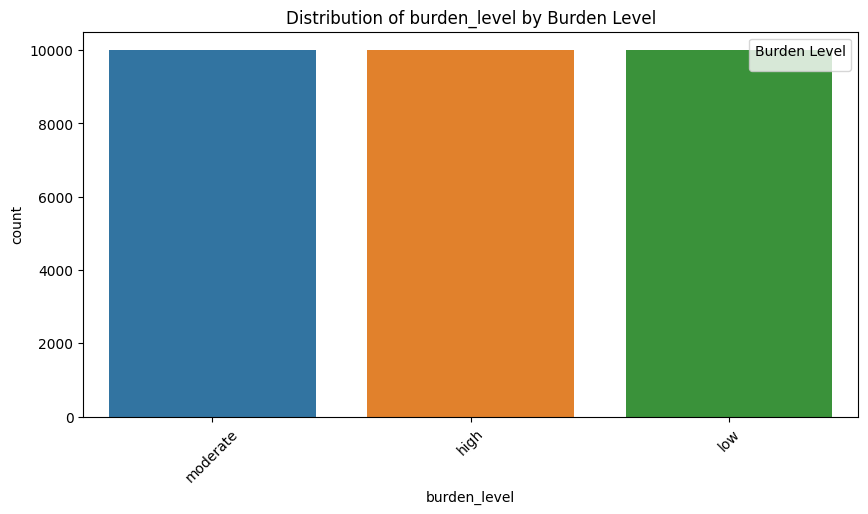

In [163]:
# Categorical features
categorical_features = df.select_dtypes(include=["object"]).columns
for feature in categorical_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=feature, hue="burden_level")
    plt.title(f"Distribution of {feature} by Burden Level")
    plt.xticks(rotation=45)
    plt.legend(title="Burden Level")
    plt.show()

In [164]:
#Convert delivery mode to numerical values
df["delivery_mode"] = df["delivery_mode"].map({"vaginal": 0, "caesarean": 1})
df.head()

,id,sex,gestational_age_weeks,birth_weight_g,head_circumference_cm,maternal_age_years,parity,delivery_mode,apgar_1min,apgar_5min,temperature_c,heart_rate_bpm,respiratory_rate_bpm,spo2_percent,bw_category,preterm_category,primary_outcome,burden_level
0,7968,F,38.2,2730,37.0,16,0,0,9,10,36.7,147,48,96,Normal_BW,Term,healthy,moderate
1,5442,F,39.8,2260,34.8,17,0,0,5,9,36.7,125,43,97,LBW,Term,low_birth_weight_term,high
2,2705,F,37.1,3030,39.4,20,2,0,9,9,36.4,120,47,97,Normal_BW,Term,healthy,high
3,7886,M,39.7,3130,18.1,15,0,0,8,10,36.8,143,54,96,Normal_BW,Term,healthy,moderate
4,3572,M,40.5,2870,34.1,23,1,0,8,7,37.2,108,46,97,Normal_BW,Term,low_birth_weight_term,low


In [165]:
#Convert sex to numerical values
df["sex"] = df["sex"].map({"M": 0, "F": 1})
df.head()

,id,sex,gestational_age_weeks,birth_weight_g,head_circumference_cm,maternal_age_years,parity,delivery_mode,apgar_1min,apgar_5min,temperature_c,heart_rate_bpm,respiratory_rate_bpm,spo2_percent,bw_category,preterm_category,primary_outcome,burden_level
0,7968,1,38.2,2730,37.0,16,0,0,9,10,36.7,147,48,96,Normal_BW,Term,healthy,moderate
1,5442,1,39.8,2260,34.8,17,0,0,5,9,36.7,125,43,97,LBW,Term,low_birth_weight_term,high
2,2705,1,37.1,3030,39.4,20,2,0,9,9,36.4,120,47,97,Normal_BW,Term,healthy,high
3,7886,0,39.7,3130,18.1,15,0,0,8,10,36.8,143,54,96,Normal_BW,Term,healthy,moderate
4,3572,0,40.5,2870,34.1,23,1,0,8,7,37.2,108,46,97,Normal_BW,Term,low_birth_weight_term,low


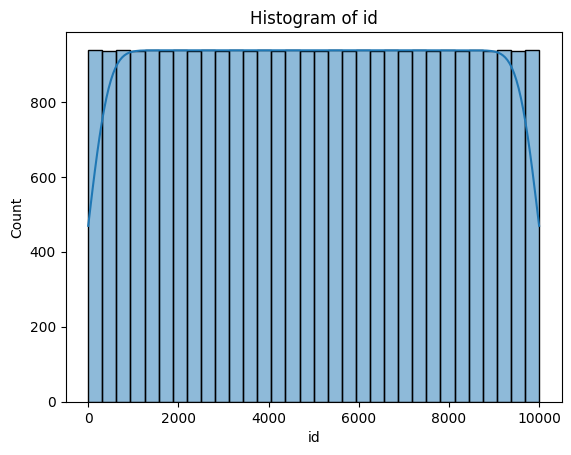

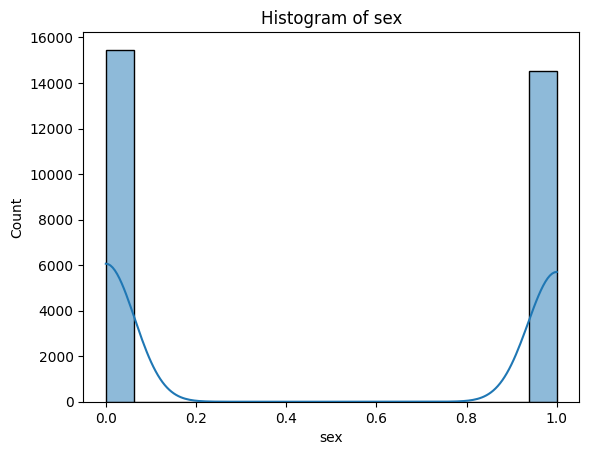

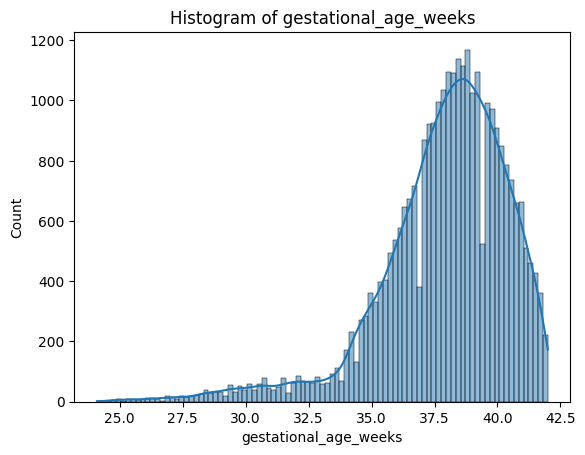

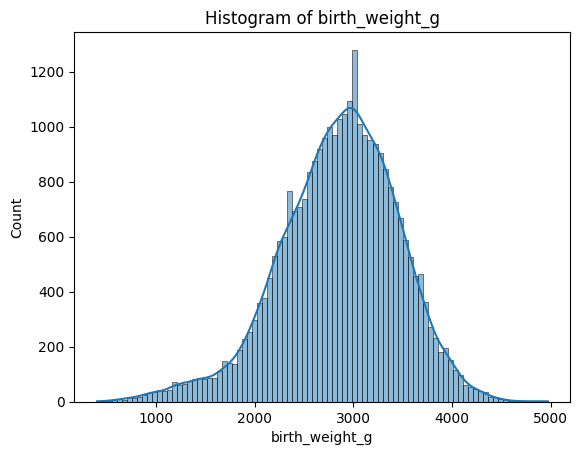

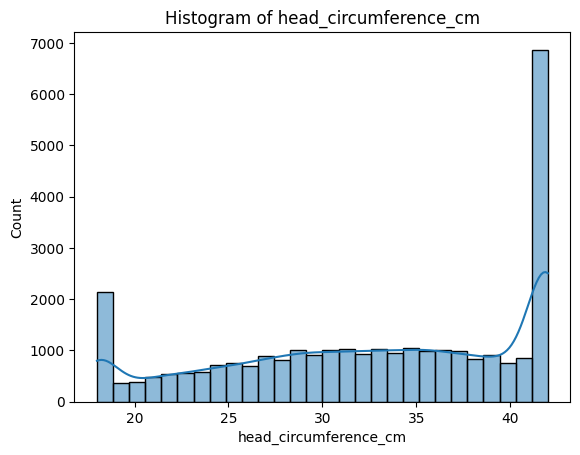

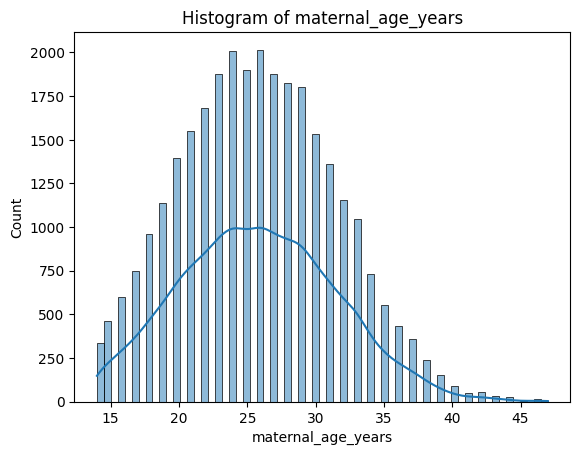

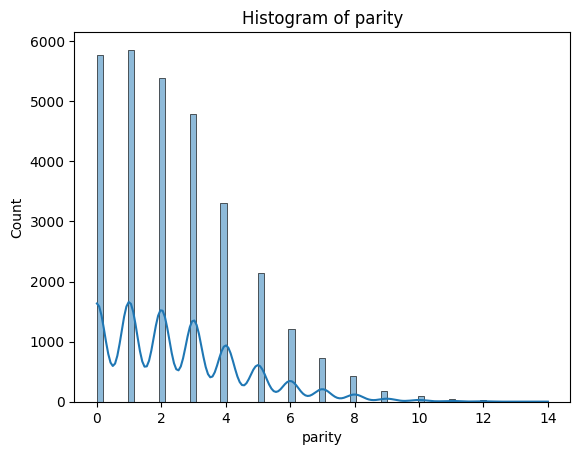

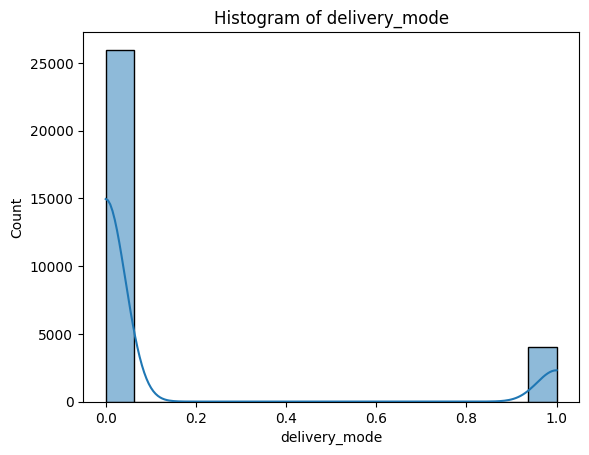

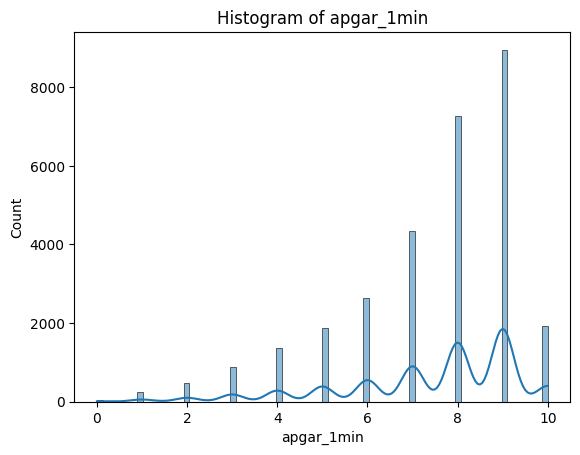

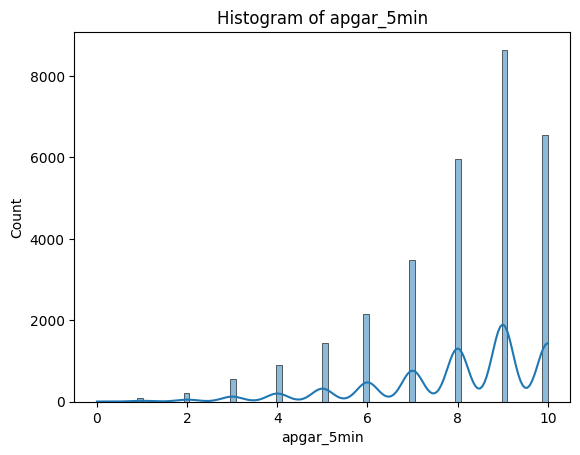

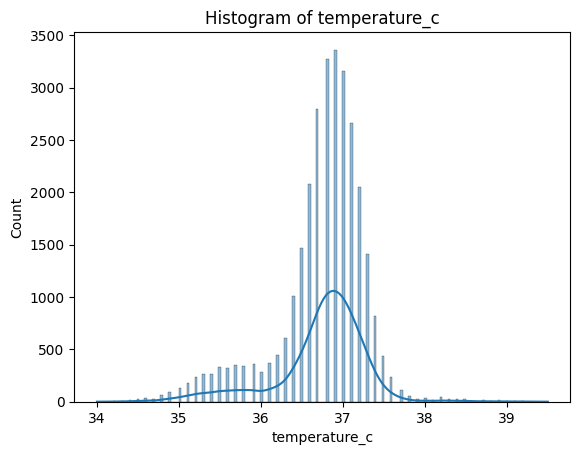

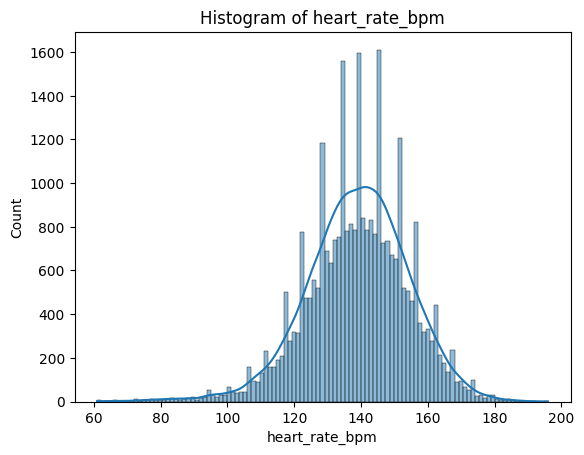

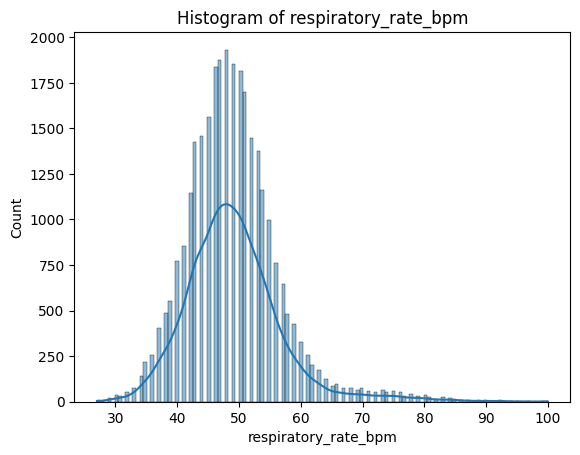

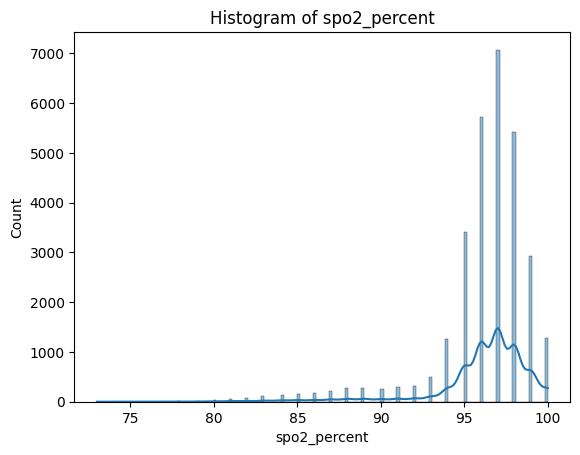

In [166]:
#Distribution of columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram of {col}")
    plt.show()

In [167]:
#Removing ID column
df.drop("id", axis=1, inplace=True)
df.head()

,sex,gestational_age_weeks,birth_weight_g,head_circumference_cm,maternal_age_years,parity,delivery_mode,apgar_1min,apgar_5min,temperature_c,heart_rate_bpm,respiratory_rate_bpm,spo2_percent,bw_category,preterm_category,primary_outcome,burden_level
0,1,38.2,2730,37.0,16,0,0,9,10,36.7,147,48,96,Normal_BW,Term,healthy,moderate
1,1,39.8,2260,34.8,17,0,0,5,9,36.7,125,43,97,LBW,Term,low_birth_weight_term,high
2,1,37.1,3030,39.4,20,2,0,9,9,36.4,120,47,97,Normal_BW,Term,healthy,high
3,0,39.7,3130,18.1,15,0,0,8,10,36.8,143,54,96,Normal_BW,Term,healthy,moderate
4,0,40.5,2870,34.1,23,1,0,8,7,37.2,108,46,97,Normal_BW,Term,low_birth_weight_term,low


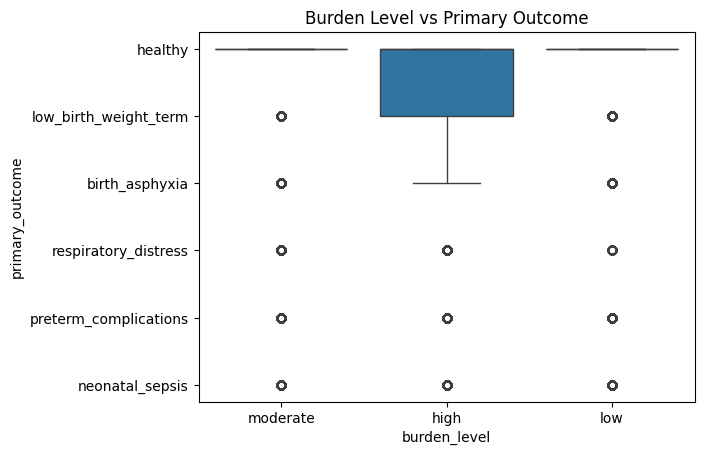

In [168]:
# Relationship between burden level and primary outcome
sns.boxplot(x="burden_level", y="primary_outcome", data=df)
plt.title("Burden Level vs Primary Outcome")
plt.show()

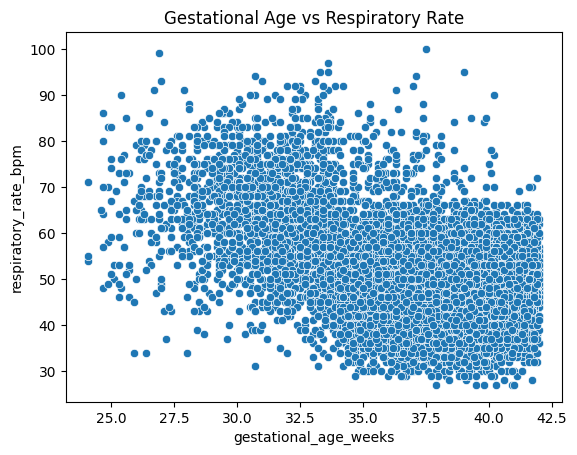

In [169]:
#Relationship between gestational age in weeks and respiratory rate
sns.scatterplot(x="gestational_age_weeks", y="respiratory_rate_bpm", data=df)
plt.title("Gestational Age vs Respiratory Rate")
plt.show()

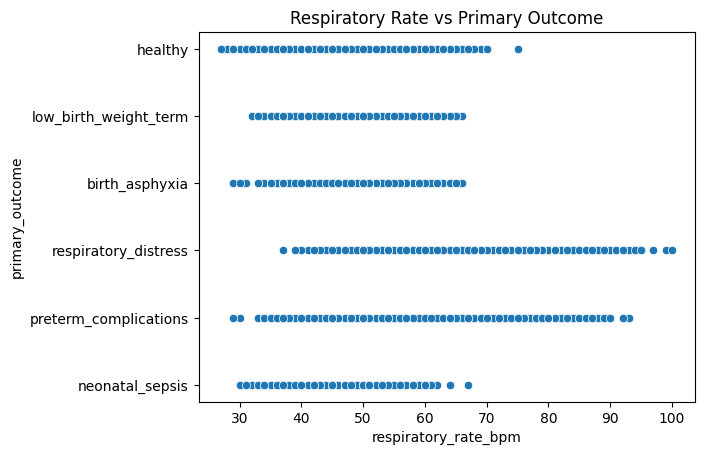

In [170]:
# Relationship between respiratory rate and primary outcome
sns.scatterplot(x="respiratory_rate_bpm", y="primary_outcome", data=df)
plt.title("Respiratory Rate vs Primary Outcome")
plt.show()


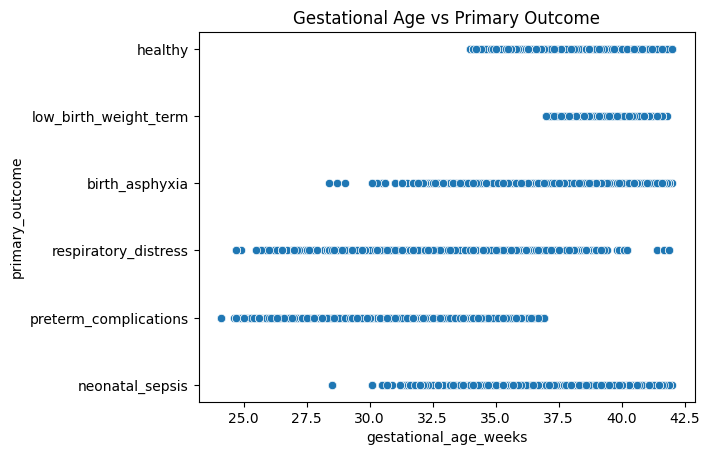

In [171]:
#Relationship between primary outcome and gestational age in weeks
sns.scatterplot(x="gestational_age_weeks", y="primary_outcome", data=df)
plt.title("Gestational Age vs Primary Outcome")
plt.show()

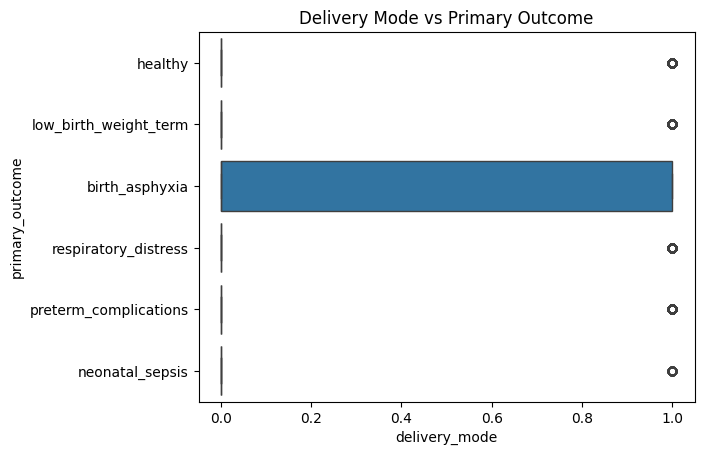

In [172]:
# Relationship betweeen delivery mode and primary outcome
sns.boxplot(x="delivery_mode", y="primary_outcome", data=df)
plt.title("Delivery Mode vs Primary Outcome")
plt.show()

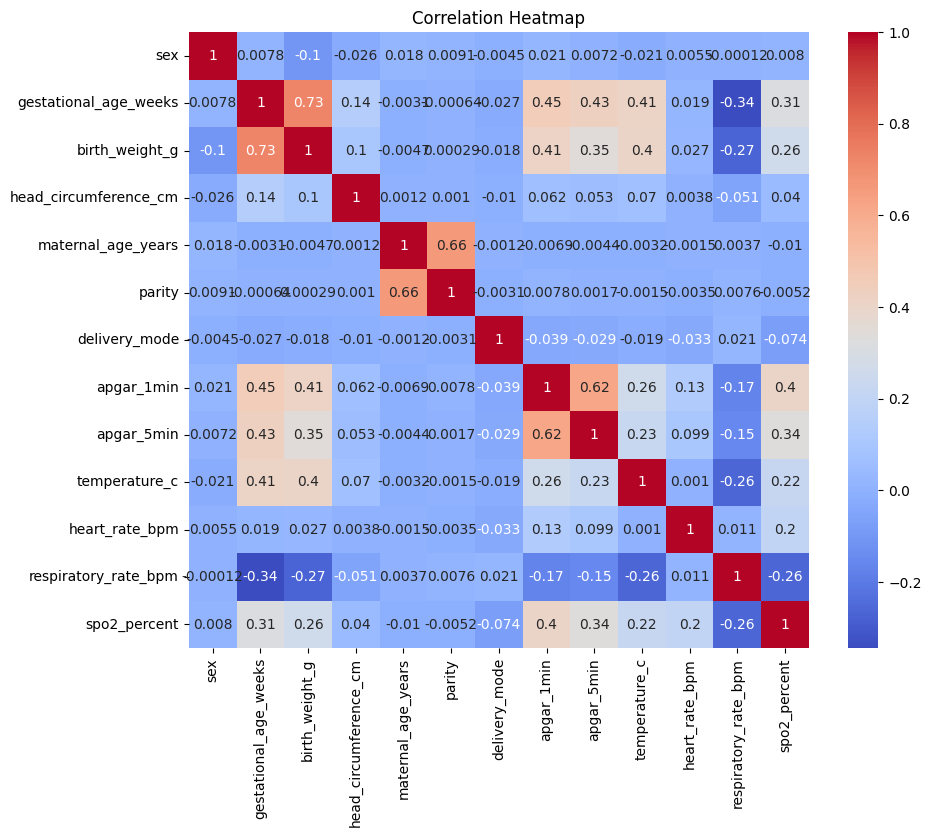

In [173]:
# Identify highly correlated features (correlation > 0.8)
cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(10,8))
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


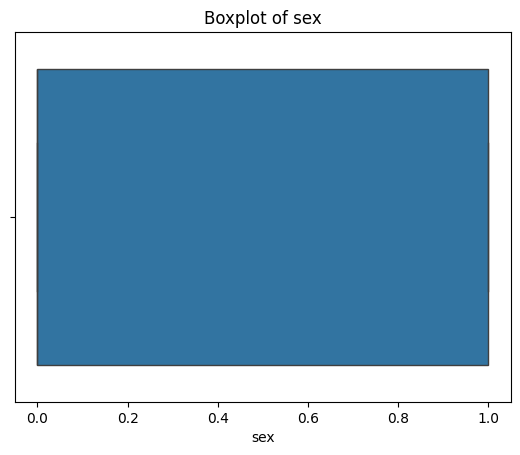

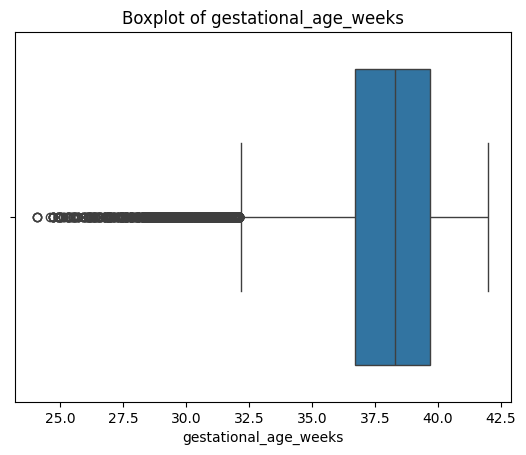

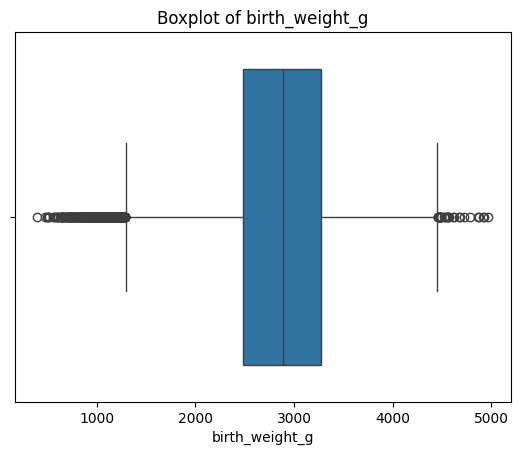

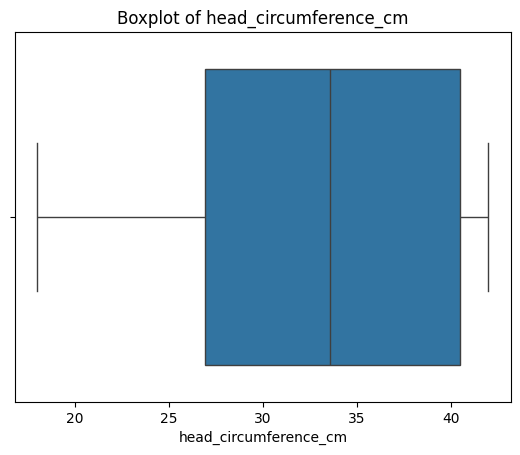

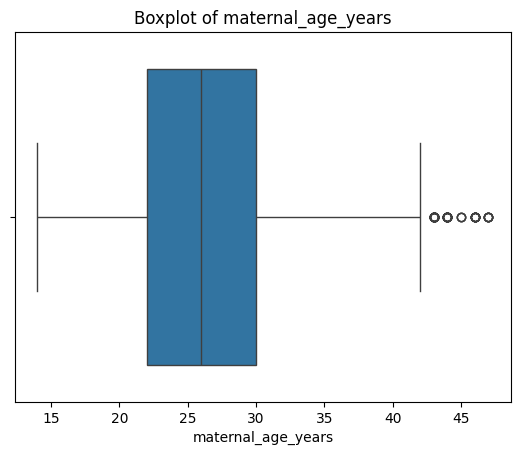

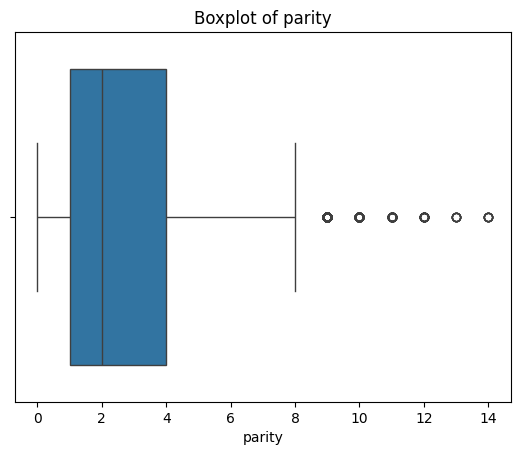

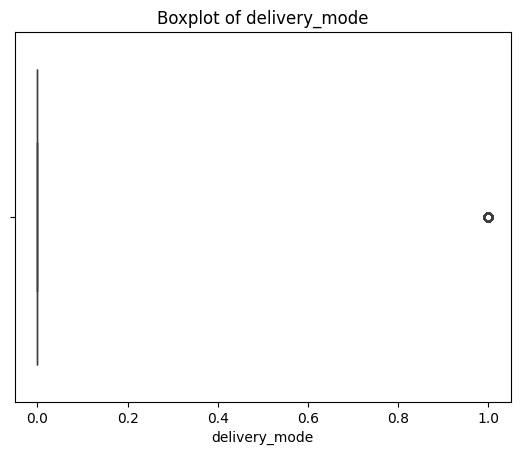

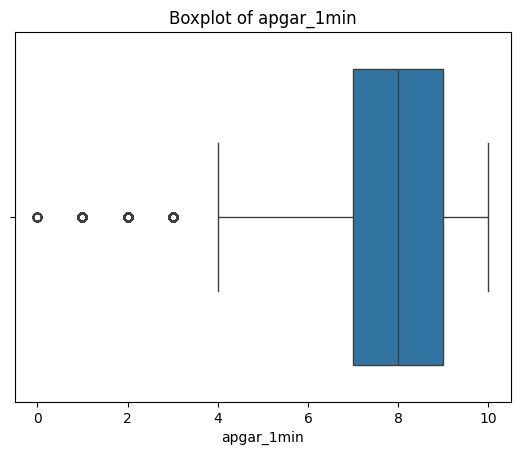

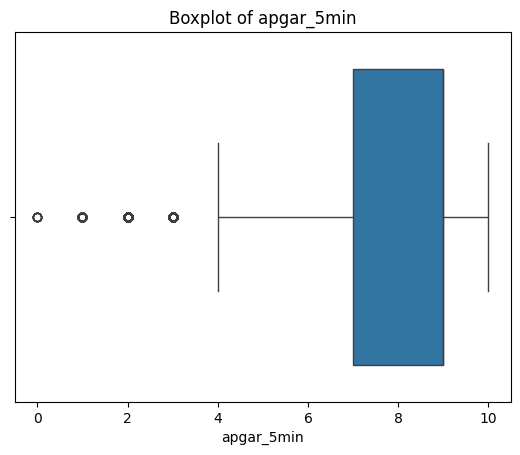

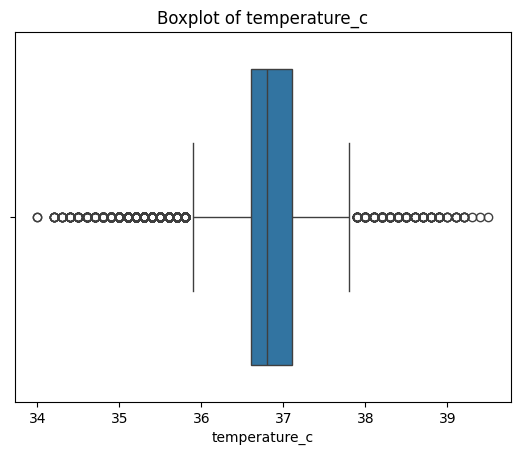

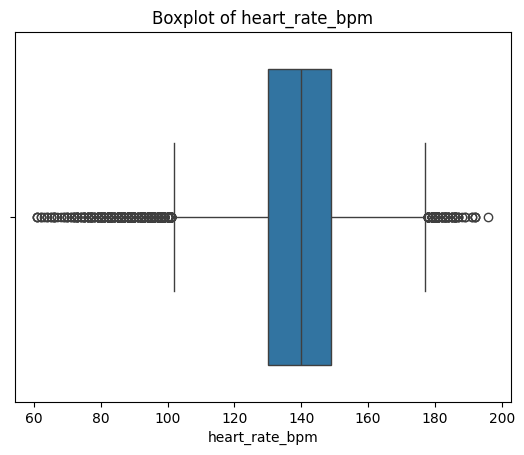

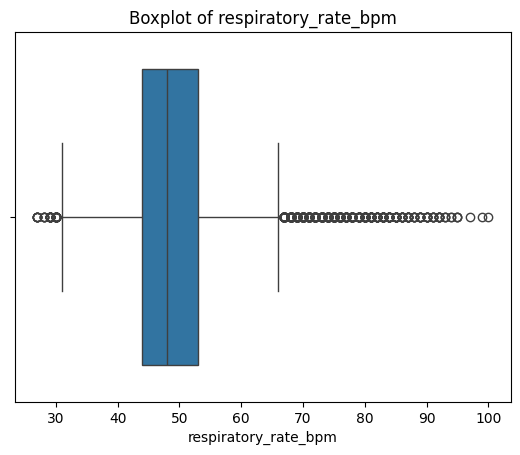

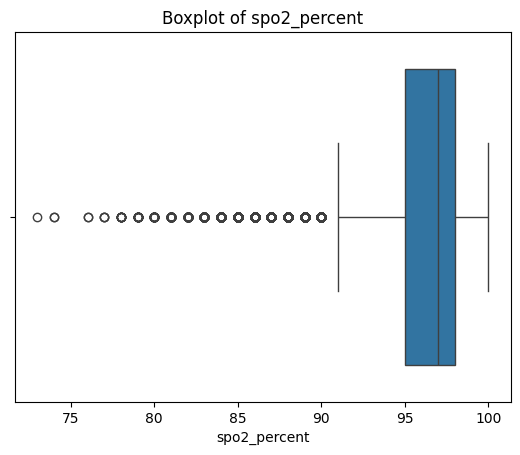

In [174]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

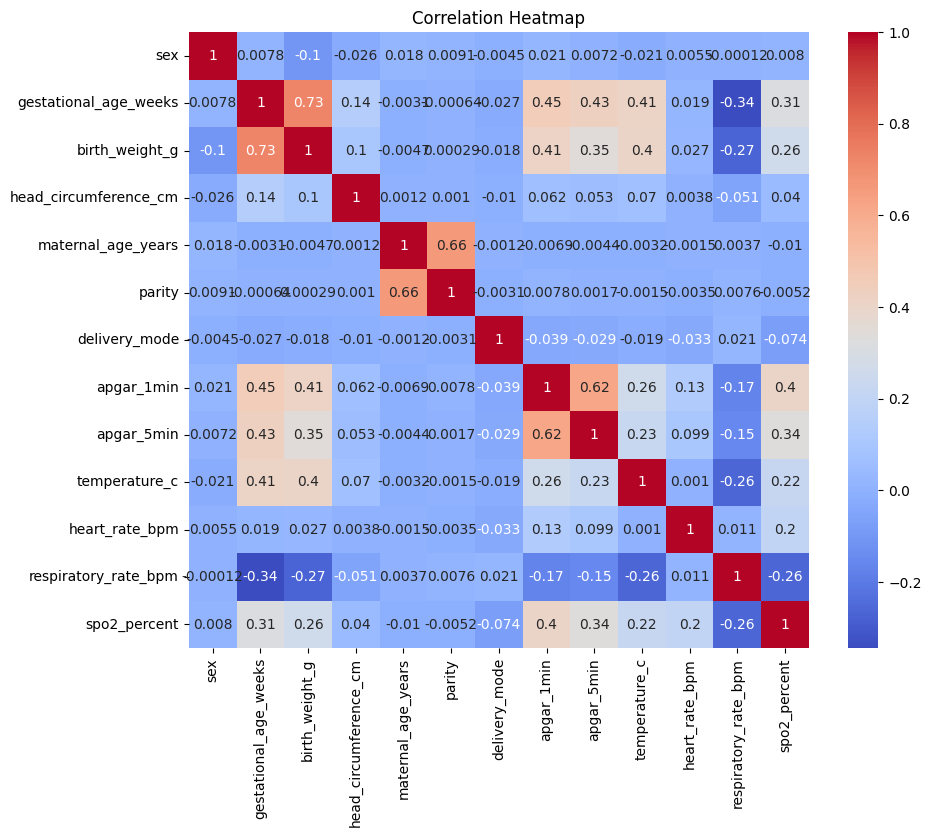

In [175]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()